In [7]:
## IMPORTS AND SETUP
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import datetime
import zipfile
import pandas as pd
from PIL import Image
import tensorflow_datasets as tfds
import wandb
import datetime
from wandb.integration.keras import WandbMetricsLogger
from dotenv import load_dotenv

load_dotenv('../.env')

WANDB_API_KEY = os.getenv("API_KEY")

# Forcer TensorFlow à utiliser le GPU
gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     try:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#     except RuntimeError as e:
#         print(e)

    
# Tensorboard setup
# %load_ext tensorboard




In [ ]:
# Paramètres
path = "../Dataset"
excluded_folder = "Dataset Livrable 2"  # Dossier à exclure
batch_size = 32
img_height = 180
img_width = 180
learning_rate= 0.001
num_epochs = 10
model_name = "CNN_Dropout_3_0.3_BatchNormalization" 



f0fa6b530663007bd73b3cdbde9ea2105c392419


In [ ]:
wandb.login(key=WANDB_API_KEY , relogin=True) 
run = wandb.init(
    project="Leyanda",
    config={
        "model_name": model_name,
        "learning_rate": learning_rate,
        "epochs": num_epochs,
    }
)

log_dir = f"logs/fit/{model_name}/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [5]:
def fix_corrupted_images(directory):
    """
    Walks through a directory to detect and fix misformatted image files.
    PNG or GIF files mislabelled as JPG are corrected.
    """
    print(f"Checking directory: {directory}")
    if not os.path.isdir(directory):
        print(f"Directory {directory} doesn't exist")
        return
    else:
        print(f"Directory {directory} exists")

    stats = {"processed": 0, "png_fixed": 0, "gif_fixed": 0, "invalid_removed": 0, "errors": 0}

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            stem, extension = os.path.splitext(file)

            if extension.lower() != '.jpg':
                continue

            stats["processed"] += 1

            try:
                with open(file_path, 'rb') as f:
                    header = f.read(4)

                if header[:4] == b'\x89PNG':
                    print(f"PNG detected: {file_path}")
                    new_path = os.path.join(root, f"{stem}.png")
                    os.rename(file_path, new_path)
                    Image.open(new_path).convert('RGB').save(file_path, "JPEG")
                    os.remove(new_path)
                    stats["png_fixed"] += 1

                elif header[:3] == b'GIF':
                    print(f"GIF detected: {file_path}")
                    new_path = os.path.join(root, f"{stem}.gif")
                    os.rename(file_path, new_path)
                    Image.open(new_path).convert('RGB').save(file_path, "JPEG")
                    os.remove(new_path)
                    stats["gif_fixed"] += 1

                elif header[:2] != b'\xff\xd8':
                    print(f"Non-JPEG file detected: {file_path}")
                    if delete_invalid:
                        os.remove(file_path)
                        stats["invalid_removed"] += 1

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                stats["errors"] += 1
                if delete_invalid:
                    os.remove(file_path)
                    stats["invalid_removed"] += 1

    print(f"\nSummary:")
    print(f"Files processed: {stats['processed']}")
    print(f"PNG files fixed: {stats['png_fixed']}")
    print(f"GIF files fixed: {stats['gif_fixed']}")
    print(f"Invalid files removed: {stats['invalid_removed']}")
    print(f"Errors encountered: {stats['errors']}")

# fix_corrupted_images("../Dataset")

In [9]:


# Vérifier le chemin et le contenu
print(f"Chemin absolu : {os.path.abspath(path)}")
if not os.path.exists(path):
    raise ValueError("Le chemin spécifié n'existe pas.")
else:
    print(f"Contenu du dossier principal : {os.listdir(path)}")

# Exclure le dossier spécifié
subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f)) and f != excluded_folder]
print(f"Sous-dossiers utilisés pour le dataset : {subfolders}")

# Créer un dataset optimisé à partir du répertoire
try:
    dataset = tf.keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",  # Les labels sont inférés à partir des noms des sous-dossiers
        label_mode="int",  # Labels sous forme d'entiers
        class_names=subfolders,  # Spécifier les classes à inclure
        color_mode="rgb",  # Images en RGB
        batch_size=batch_size,
        image_size=(img_height, img_width),  # Redimensionner les images
        shuffle=True,
        seed=123,
        validation_split=None,  # Pas de validation split ici
        subset=None,
        interpolation="bilinear",
        follow_links=False
    )

    # Afficher les classes détectées
    class_names = dataset.class_names
    print(f"Classes détectées : {class_names}")

    # Précharger les données pour une meilleure performance
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    # Afficher un exemple
    for images, labels in dataset.take(1):
        print(f"Images batch shape : {images.shape}")
        print(f"Labels batch : {labels.numpy()}")

except Exception as e:
    print(f"Erreur lors de la création du dataset : {e}")

Chemin absolu : /tf/projet/Dataset
Contenu du dossier principal : ['Dataset Livrable 2', 'Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Sous-dossiers utilisés pour le dataset : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Found 41398 files belonging to 5 classes.
Classes détectées : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Images batch shape : (32, 180, 180, 3)
Labels batch : [4 4 1 1 2 4 0 4 2 0 4 0 4 1 2 3 0 0 1 1 1 1 1 2 0 0 4 1 4 2 2 2]


2025-04-08 08:43:49.166003: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Proportions des splits
train_split = 0.8
val_split = 0.1
test_split = 0.1

# Calculer les tailles
dataset_size = tf.data.experimental.cardinality(dataset).numpy()  # Plus rapide que len(dataset)
train_size = int(train_split * dataset_size)
val_size = int(val_split * dataset_size)

# Mélanger le dataset
# dataset = dataset.shuffle(buffer_size=500, seed=123)

# Diviser le dataset
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size)

# Ajouter prefetch pour optimiser les performances
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
## MODEL CREATION

def create_model(img_height = 180, img_width = 180, num_classes = 5):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(img_height, img_width, 3)),
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),  
        
        tf.keras.layers.Dense(num_classes)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
                  
    model.save(f'./models/{model_name}.keras', include_optimizer=False)
                  
    return model

model = create_model(img_height, img_width, len(class_names))


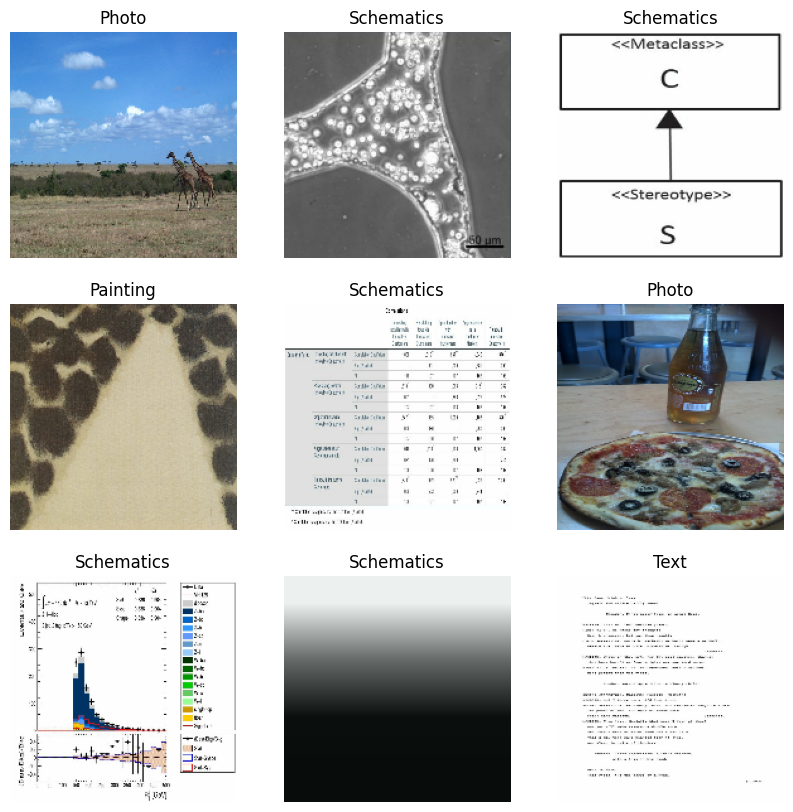

In [11]:
plt.figure(figsize=(10, 10))

# Re-initialize the dataset iterator
train_ds_iter = iter(train_ds)  # Create a fresh iterator from the dataset

# Fetch one batch of images and labels
images, labels = next(train_ds_iter)

# Display up to 9 images
for i in range(min(9, len(images))):  # Limit to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 129600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    16,588,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,613,413 (63.38 MB)

 Trainable params: 16,613,285 (63.37 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
import wandb
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

class ConfusionMatrixCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, class_names):
        super().__init__()
        self.val_data = val_data
        self.class_names = class_names

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []

        for images, labels in self.val_data:
            preds = self.model.predict(images)
            y_true.extend(labels.numpy())
            y_pred.extend(np.argmax(preds, axis=1))

        # 💠 Logger le graphique dans WandB
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.class_names)
        disp.plot(ax=ax, xticks_rotation=45)
        plt.title(f"Confusion Matrix - Epoch {epoch + 1}")
        plt.tight_layout()

        # 🔁 Logger l’image
        wandb.log({"Confusion Matrix Image": wandb.Image(fig)}, step=epoch)
        plt.close(fig)

        # 🔁 Logger la vraie matrice pour les dashboards WandB interactifs
        wandb.log({"Confusion Matrix Data": wandb.plot.confusion_matrix(
            probs=None,
            y_true=y_true,
            preds=y_pred,
            class_names=self.class_names
        )}, step=epoch)


In [14]:
def create_callbacks(model_name="default_model", tensorboard=True, early_stopping=True, model_checkpoint=True, conf_matrix=False, val_data=None, class_names=None):
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    callbacks = []

    if tensorboard:
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        callbacks.append(tensorboard_callback)

    if early_stopping:
        early_stopping_callback = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True
        )
        callbacks.append(early_stopping_callback)

    if model_checkpoint:
        checkpoint_dir = "checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, f"{model_name}_{timestamp}.keras"),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
        callbacks.append(model_checkpoint_callback)

    if conf_matrix and val_data is not None and class_names is not None:
        cm_callback = ConfusionMatrixCallback(val_data=val_data, class_names=class_names)
        callbacks.append(cm_callback)

    return callbacks

callbacks = [WandbMetricsLogger()] + create_callbacks(
    model_name="CNN_Model",
    tensorboard=True,
    early_stopping=True,
    model_checkpoint=True,
    conf_matrix=True,
    val_data=val_ds,
    class_names=class_names
)

In [15]:


history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=num_epochs,
  callbacks=callbacks
)

run.finish()

Epoch 1/10


I0000 00:00:1744056534.728028   82449 service.cc:146] XLA service 0x7f942c005df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744056534.728104   82449 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-04-07 20:08:54.794111: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-07 20:08:55.077675: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


   4/1035 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.2051 - loss: 34.1488 

I0000 00:00:1744056538.799528   82449 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 564/1035 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.2612 - loss: 4.9627

...

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9



Epoch 10: val_loss did not improve from 1.48975


Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

epoch/accuracy,█▁▆▆▅▆▇▇▆▅
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,█▁▄▃▃▃▃▃▂▂
epoch/val_loss,█▃▁▁▁▁▂▁▂▁
epoch/accuracy,0.24296
epoch/epoch,9
epoch/learning_rate,0.001
epoch/loss,1.48705
epoch/val_accuracy,0.2374


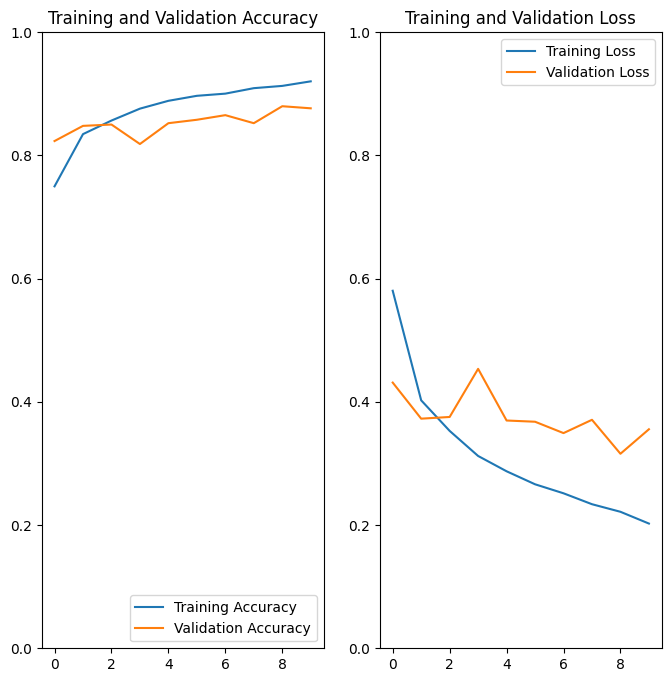

In [ ]:
# acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']

# loss = history.history['loss']
# val_loss = history.history['val_loss']

# epochs_range = range(len(history.epoch))

# plt.figure(figsize=(8, 8))
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, acc, label='Training Accuracy')
# plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# plt.ylim(0, 1)
# plt.legend(loc='lower right')
# plt.title('Training and Validation Accuracy')

# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, loss, label='Training Loss')
# plt.plot(epochs_range, val_loss, label='Validation Loss')
# plt.ylim(0, 1)
# plt.legend(loc='upper right')
# plt.title('Training and Validation Loss')
# plt.show()


In [ ]:
# model.load_weights("./checkpoints/CNN_Model_20250403-083508.keras")

In [16]:
model.evaluate(test_ds)

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


130/130 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.2285 - loss: 1.4946


[1.4896917343139648, 0.23493975400924683]

In [ ]:
 
import numpy as np

# Utiliser les vraies classes détectées dans le dataset
# Assurez-vous que `class_names` est défini à partir de votre dataset
# Exemple : class_names = dataset.class_names
print(f"Classes disponibles : {class_names}")

model = tf.keras.models.load_model('./models/'+model_name+'.keras')
model.load_weights('./checkpoints/CNN_Model_20250407-200850.keras')
# Charger l'image
img_path = 'peinture_vernon.jpg'  # Remplacez par le chemin de votre image
img = tf.keras.image.load_img(img_path, target_size=(img_height, img_width)) 

# Prétraiter l'image
img_array = tf.keras.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension pour le batch

# Faire une prédiction
predictions = model.predict(test_ds)

# Trouver l'indice de la classe avec la probabilité la plus élevée
predicted_class_index = np.argmax(predictions[0])

# Afficher le nom de la classe prédite
predicted_class_name = class_names[predicted_class_index]
print(f"Classe prédite : {predicted_class_name}")

NameError: name 'class_names' is not defined